# 시간대별 미세먼지 일중 변동 분석

**목적**: 하루 24시간 동안 PM10/PM2.5가 시간대별로 얼마나 오르내리는지 확인한다.

**배경**: 75% 규칙(관측 18시간 미만 무효화)으로 버려지는 날들을,
"특정 시간대 관측값만으로 일평균을 추정"하는 방식으로 살릴 수 있는지 판단하기 위함.

**판단 기준**
- 시간대별 평균의 증감폭이 작다(예: 전체 평균 대비 ±10% 이내) -> 부분 관측 평균도 일평균의 근사로 쓸 여지 있음
- 증감폭이 크다 -> 어떤 시간대가 관측됐냐에 따라 부분 평균이 편향되므로, 현행(무효화 유지)이 안전

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 분석할 연도 파일 (노트북이 src/ 기준일 때의 상대경로. 필요 시 수정)
RAW_PATH = "../data/raw/2019.xlsx"

# 시간 단위 원자료 로드 (수 분 소요될 수 있음)
sheets = pd.read_excel(RAW_PATH, sheet_name=None, engine="calamine")
raw = pd.concat(sheets.values(), ignore_index=True)
print(raw.shape)

In [ ]:
# 측정일시(YYYYMMDDHH)에서 시간(hour) 추출. 표기는 01~24.
s = raw["측정일시"].astype(str).str.replace("-", "", regex=False)
raw["hour"] = s.str[8:10].astype(int)

print("hour 유니크 값:", sorted(raw["hour"].unique()))  # 01~24 확인용

In [ ]:
# 시간대별 전국 평균 (결측은 mean에서 자동 제외)
hourly = raw.groupby("hour")[["PM10", "PM25"]].mean()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=hourly, x=hourly.index, y="PM10", marker="o", label="PM10", ax=ax)
sns.lineplot(data=hourly, x=hourly.index, y="PM25", marker="o", label="PM2.5", ax=ax)
ax.set_title("시간대별 평균 미세먼지 농도 (전국, 2019)")
ax.set_xlabel("시간 (01~24시)")
ax.set_ylabel("농도 (µg/m³)")
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

In [ ]:
# 증감폭 정량화: 전체 평균 대비 시간대별 상대 편차 (%)
for col in ["PM10", "PM25"]:
    overall = raw[col].mean()
    rel = (hourly[col] / overall - 1) * 100
    print(f"=== {col} ===")
    print(f"전체 평균: {overall:.1f} µg/m³")
    print(f"시간대별 상대 편차: 최소 {rel.min():+.1f}% (при {rel.idxmin()}시) ~ 최대 {rel.max():+.1f}% ({rel.idxmax()}시)")
    print()

## 주의: 계절에 따라 일중 패턴이 다를 수 있음

연간 평균 곡선이 평평해 보여도, 겨울(난방·정체)과 여름(광화학 반응)의 패턴이 서로 다른 방향으로
상쇄된 결과일 수 있다. 우리 분석 대상이 겨울철이므로 계절별로도 확인한다.

In [ ]:
raw["month"] = s.str[4:6].astype(int)
raw["season"] = raw["month"].map(
    lambda m: "겨울(12~3월)" if m in [12, 1, 2, 3] else "그 외(4~11월)"
)

seasonal_hourly = raw.groupby(["season", "hour"])[["PM10", "PM25"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["PM10", "PM25"]):
    sns.lineplot(data=seasonal_hourly, x="hour", y=col, hue="season", marker="o", ax=ax)
    ax.set_title(f"{col} 시간대별 평균: 계절 비교")
    ax.set_xlabel("시간 (01~24시)")
    ax.set_ylabel("농도 (µg/m³)")
plt.tight_layout()
plt.show()

## 해석 및 다음 결정

- 상대 편차가 ±10% 이내로 평평하면: 부분 관측일을 살리는 방안(시간대 통계 활용)을 검토할 수 있다.
  단, 그 경우에도 "어느 시간대가 결측되는 경향이 있는지"(결측이 특정 시간대에 몰리는지)를
  추가로 확인해야 안전하다.
- 편차가 크면: 현행 75% 무효화 유지가 안전하며, 이 그래프 자체가 그 근거 자료가 된다.
- 어느 쪽이든 이 분석은 보고서의 '결측치 처리 근거' 섹션에 사용 가능.

---
# 추가 분석: 2015~2018 월별 결측치 비율

**목적**: 2015-2018 구간의 결측(특히 PM2.5 약 40%)이 시기적으로 어떻게 분포하는지 확인한다.
- 측정망 확충 가설이 맞다면: PM2.5 결측률이 2015년에 가장 높고 시간이 갈수록 단조 감소해야 한다
- 특정 월에 결측이 몰려 있다면: 다른 원인(대규모 점검 등)을 의심해야 한다

여기서의 결측률은 시간 단위 원자료 기준(관측 0시간 원천 결측 포함)이다.
전처리의 75% 규칙 무효화(2~3%)와는 별개의 수치임에 유의.

In [7]:
# 2015-2018 파일 로드 (필요 컬럼만 - 메모리 절약. 수 분 소요)
RAW_1518_PATH = "../data/raw/2015-2018.xlsx"
POLLUTANTS = ["SO2", "CO", "O3", "NO2", "PM10", "PM25"]

sheets_1518 = pd.read_excel(
    RAW_1518_PATH,
    sheet_name=None,
    engine="calamine",
    usecols=["지역", "측정일시"] + POLLUTANTS,   # "지역" 추가
)
raw_1518 = pd.concat(sheets_1518.values(), ignore_index=True)
print(raw_1518.shape)

(11826111, 8)


In [8]:
# 연-월 추출 후 월별 결측률(%) 계산
ym = raw_1518["측정일시"].astype(str).str[:6]  # YYYYMM
monthly_missing = (
    raw_1518[POLLUTANTS].isna().groupby(ym).mean() * 100
).round(1)
monthly_missing.index = pd.to_datetime(monthly_missing.index, format="%Y%m")

with pd.option_context("display.max_rows", None):
    print(monthly_missing)

            SO2   CO   O3  NO2  PM10  PM25
측정일시                                      
2015-01-01  4.2  4.2  3.8  3.0   3.0  67.5
2015-02-01  4.0  3.7  3.7  2.9   2.9  67.4
2015-03-01  4.5  5.0  4.5  3.4   3.5  67.4
2015-04-01  4.9  4.9  4.8  3.6   4.2  66.4
2015-05-01  4.0  4.0  3.5  2.9   2.7  65.5
2015-06-01  4.4  4.2  4.0  3.4   5.4  65.3
2015-07-01  5.8  6.4  6.4  5.5  22.6  67.2
2015-08-01  5.5  5.8  5.0  5.1  24.7  66.8
2015-09-01  6.3  6.2  5.5  5.2  26.6  67.4
2015-10-01  5.1  5.0  4.5  4.3  23.6  65.6
2015-11-01  5.4  4.8  4.4  3.9  12.0  64.4
2015-12-01  5.9  5.2  4.8  4.2   4.6  60.9
2016-01-01  3.8  3.9  3.2  2.6   2.7  57.6
2016-02-01  3.8  3.7  3.2  3.0   2.2  56.7
2016-03-01  3.8  3.9  3.4  2.5   2.7  54.5
2016-04-01  4.0  3.9  3.6  3.2   3.0  53.5
2016-05-01  4.1  4.0  3.7  3.1   3.3  50.0
2016-06-01  5.2  5.1  4.6  4.3   4.2  49.7
2016-07-01  5.2  5.4  5.6  4.4   6.0  49.0
2016-08-01  5.3  6.0  5.9  4.8   5.7  47.8
2016-09-01  4.3  4.9  4.2  3.4   5.9  45.5
2016-10-01 

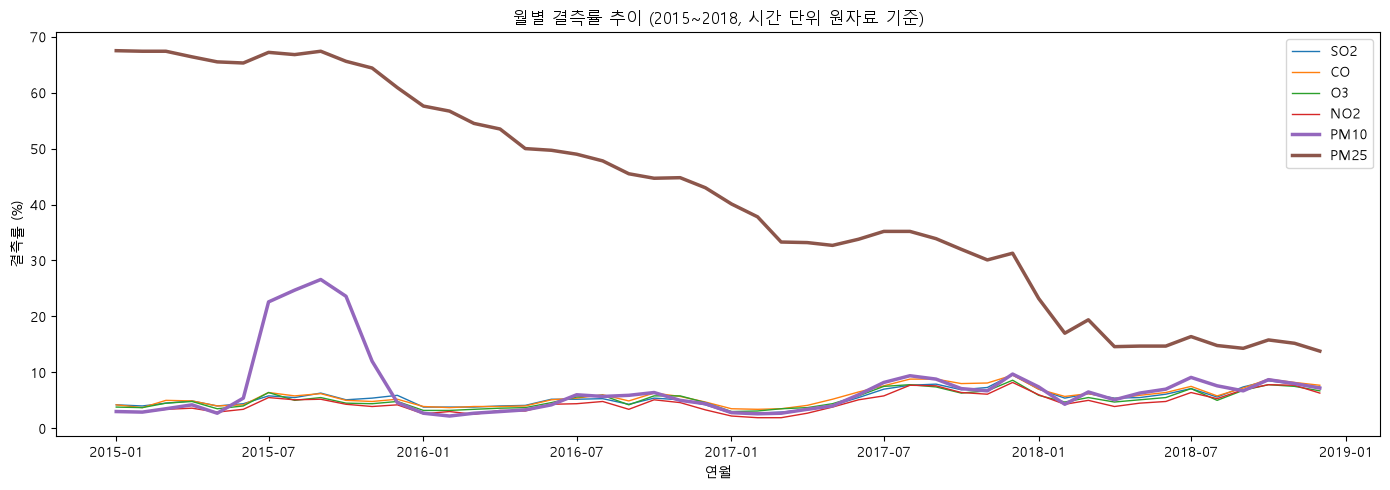

In [9]:
# 시각화: 월별 결측률 추이 (PM10/PM2.5 강조)
fig, ax = plt.subplots(figsize=(14, 5))
for col in POLLUTANTS:
    lw = 2.5 if col in ("PM10", "PM25") else 1
    ax.plot(monthly_missing.index, monthly_missing[col], label=col, linewidth=lw)
ax.set_title("월별 결측률 추이 (2015~2018, 시간 단위 원자료 기준)")
ax.set_xlabel("연월")
ax.set_ylabel("결측률 (%)")
ax.legend()
plt.tight_layout()
plt.show()

## 해석 포인트

- PM2.5 결측률이 단조 감소하면 -> 측정망 확충 서사 확정 (설치년도 데이터와 교차 검증됨)
- 다른 오염물질(SO2, CO 등)의 결측률이 낮고 안정적이면 -> PM2.5 결측이 '장비 미설치' 특유의
  문제임을 대비(contrast)로 보여줄 수 있음
- 이 그래프는 보고서의 데이터 품질 섹션(rubric 2)과 편향 섹션(rubric 6)에 사용

In [10]:
raw_1518["sido"] = raw_1518["지역"].str.split().str[0]
raw_1518["ym"] = pd.to_datetime(raw_1518["측정일시"].astype(str).str[:6], format="%Y%m")

# 시/도 x 연월별 PM10/PM25 결측률(%)
regional_missing = (
    raw_1518.groupby(["sido", "ym"])[["PM10", "PM25"]]
    .agg(lambda s: s.isna().mean() * 100)
    .round(1)
)
regional_missing.head(10)

PM10  PM25
sido ym                    
강원   2015-01-01   1.5  64.8
     2015-02-01   9.9  65.0
     2015-03-01   1.6  64.1
     2015-04-01   4.3  66.6
     2015-05-01   5.2  65.5
     2015-06-01   1.7  65.2
     2015-07-01   7.0  65.9
     2015-08-01  45.7  64.6
     2015-09-01  13.2  65.3
     2015-10-01  20.4  65.8

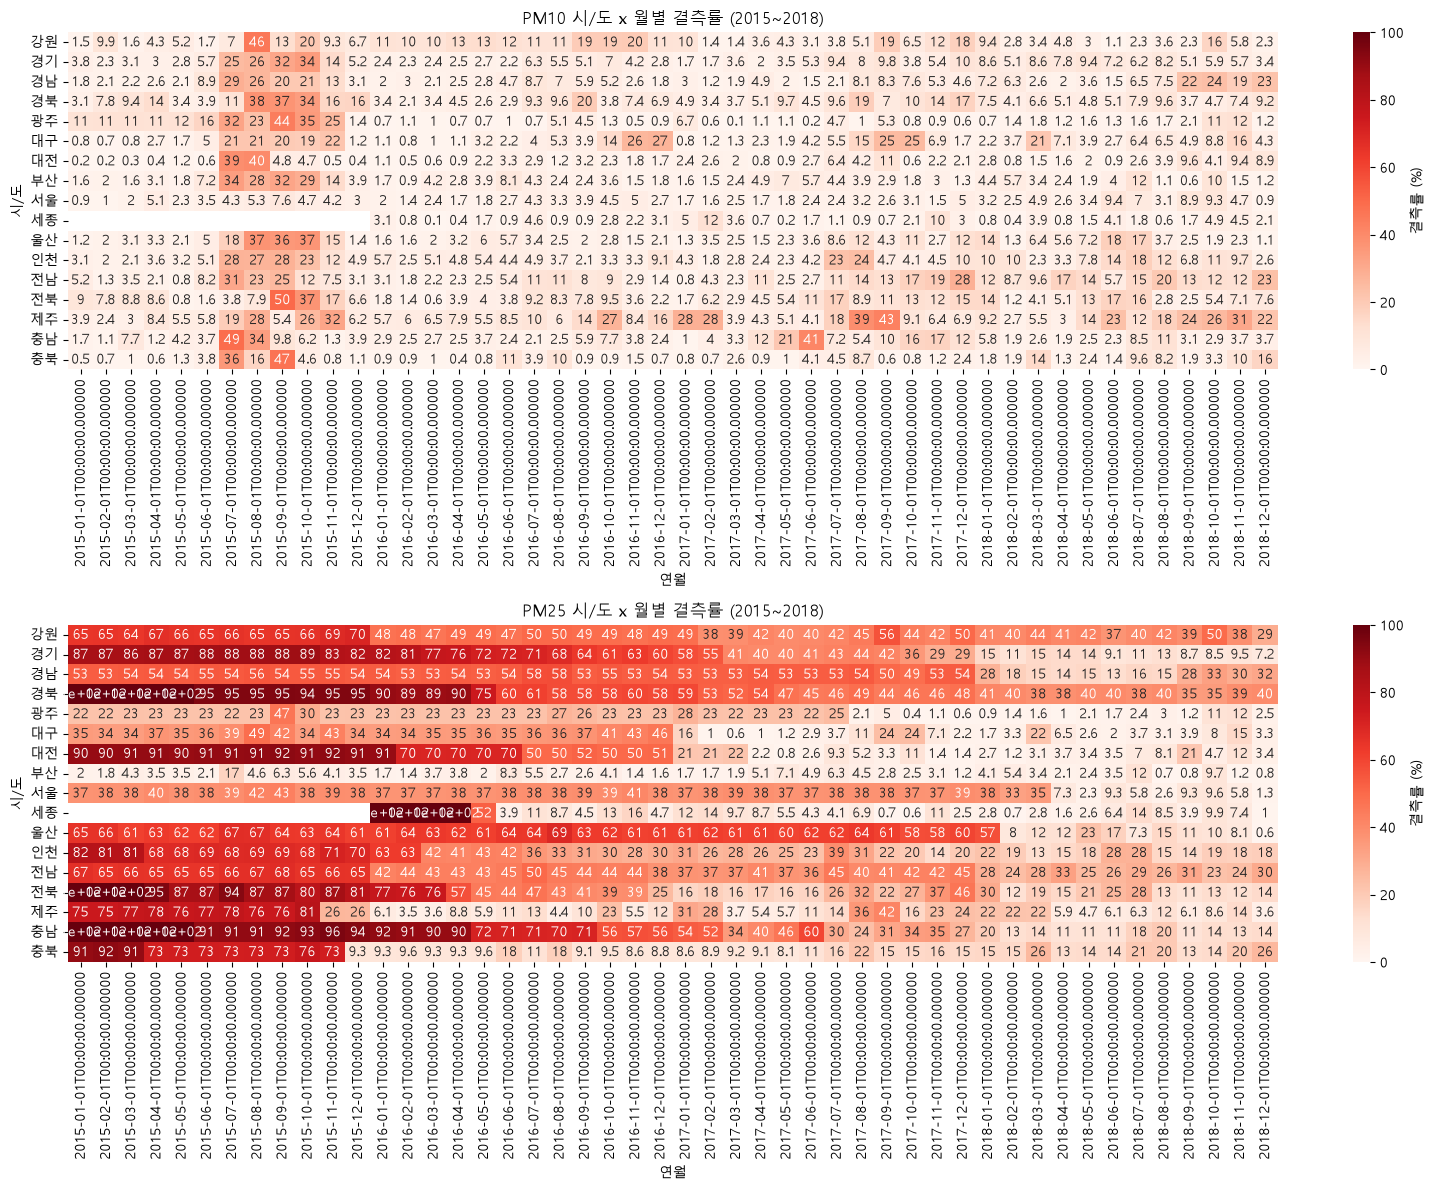

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
for ax, col in zip(axes, ["PM10", "PM25"]):
    pivot = regional_missing[col].unstack("ym")
    sns.heatmap(pivot, cmap="Reds", vmin=0, vmax=100,
                cbar_kws={"label": "결측률 (%)"}, ax=ax, annot=True)
    ax.set_title(f"{col} 시/도 x 월별 결측률 (2015~2018)")
    ax.set_xlabel("연월")
    ax.set_ylabel("시/도")
plt.tight_layout()
plt.show()